# Library Import

In [5]:
celebA = False
loss_type = "MultiSimilarity"  # Circle

In [6]:
%matplotlib inline
import numpy as np
import random
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from src.ml.resNet18 import SiameseNetworkCosine
from src.preprocessing.dataLoader_Siamase import SiameseNetworkDataset
import torch
import torchvision.transforms as transforms

In [7]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed before any operations
set_seed(42)

# Face Dataset

# Network

In [8]:
import pytorch_metric_learning.losses as losses
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = SiameseNetworkCosine().to(DEVICE)

if loss_type == "Circle":
    criterion = losses.CircleLoss(m = 0.25, gamma = 256).to(DEVICE)
elif loss_type == "MultiSimilarity":
    criterion = losses.MultiSimilarityLoss().to(DEVICE)


/home/arman/.conda/envs/RAML/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/arman/.conda/envs/RAML/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from sklearn.model_selection import KFold
import numpy as np
import mlflow
from colorama import Fore, Style, init
from tqdm.auto import tqdm
import warnings

# Initialize colorama
init()

# Constants and setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")

# Define your SiameseNetwork and SiameseNetworkDataset classes here
# (Assuming these are defined elsewhere in your code)

# Transformation pipeline
transformation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.1, 2.3), value='random')
])

# Prepare the full dataset
full_folder_dataset = datasets.ImageFolder(root="data/faces/all")
full_siamese_dataset = SiameseNetworkDataset(imageFolderDataset=full_folder_dataset,
                                           transform=transformation)

# Set up K-Fold cross validation
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True)

# MLflow setup
experiment_name = f"{loss_type}_loss"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

mlflow.set_experiment(experiment_name)

# Training variables
best_overall_f1 = -1
best_fold_index = -1
all_fold_results = []
radians = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(full_siamese_dataset)):
    print(f'\n{"="*40}')
    print(f'FOLD {fold + 1}/{k_folds}')
    print(f'{"="*40}\n')
    
    # Initialize metrics for this fold
    batch_loss_history = []
    batch_val_loss_history = []
    epoch_loss_history = []
    epoch_val_loss_history = []
    val_accuracy_history = []
    val_precision_history = []
    val_recall_history = []
    val_f1_history = []
    
    # Create subsets and dataloaders
    train_subsampler = Subset(full_siamese_dataset, train_ids)
    val_subsampler = Subset(full_siamese_dataset, val_ids)
    
    train_dataloader = DataLoader(train_subsampler, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subsampler, batch_size=32, shuffle=False)
    
    # Reinitialize model and optimizer for each fold
    net = SiameseNetworkCosine().to(DEVICE)
    optimizer = optim.AdamW(net.parameters(), lr=1e-4, weight_decay=1e-4)
    
    # Early stopping variables
    best_val_loss = np.inf
    epochs_no_improve = 0
    early_stop = False
    patience = 5
    
    # MLflow tracking for this fold
    with mlflow.start_run(run_name=f"Fold_{fold}", nested=True):
        mlflow.log_param("fold", fold)
        
        NUM_EPOCHS = 60
        for epoch in range(NUM_EPOCHS):
            if early_stop:
                print(Fore.RED + f"Early stopping triggered after {epoch} epochs!")
                break

            # Training phase
            net.train()
            cum_loss = 0
            pbar = tqdm(enumerate(train_dataloader, 0), total=len(train_dataloader),
                        desc=Fore.CYAN + f"Epoch {epoch + 1}/{NUM_EPOCHS} [Training]" + Style.RESET_ALL, leave=True)

            for i, (img0, img1, label, label0, label1) in pbar:
                img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
                label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

                optimizer.zero_grad()
                output1, output2 = net(img0, img1)

                if loss_type == "contrastive":
                    loss = criterion(output1, output2, label)
                else:
                    embeddings = torch.cat([output1, output2])
                    labels = torch.cat([label0, label1])
                    loss = criterion(embeddings, labels)

                loss.backward()
                optimizer.step()

                cum_loss += loss.item()
                batch_loss_history.append(loss.item())
                mlflow.log_metric("batch_train_loss", loss.item(), step=epoch * len(train_dataloader) + i)

                avg_train_loss = cum_loss / (i + 1)
                pbar.set_postfix({
                    'TrL': f"{avg_train_loss:.4f}",
                    'VL': f"{epoch_val_loss_history[-1]:.4f}" if epoch_val_loss_history else '--',
                    'Acc': f"{val_accuracy_history[-1]:.4f}" if val_accuracy_history else '--',
                })
            
            epoch_loss_history.append(avg_train_loss)

            # Validation phase
            net.eval()
            val_loss = 0.0
            total_samples = 0
            correct_predictions = 0
            true_positives = 0
            false_positives = 0
            false_negatives = 0
            
            # For ROC AUC calculation
            all_distances = []
            all_labels = []

            with torch.no_grad():
                for img0, img1, label, label0, label1 in val_dataloader:
                    img0, img1, label = img0.to(DEVICE), img1.to(DEVICE), label.to(DEVICE)
                    label0, label1 = label0.to(DEVICE), label1.to(DEVICE)

                    output1, output2 = net(img0, img1)
                    distances =F.cosine_similarity(output1, output2)
            
                    
                    # Store distances and labels for ROC AUC
                    all_distances.extend(distances.cpu().numpy())
                    all_labels.extend(label.cpu().numpy())
                    
                    for i in range(len(distances)):
                        euclid = distances[i].item()
                        label_pred = 0 if euclid >= 0.5 else 1
                        true_label = label[i].item()
                    
                        total_samples += 1
                        correct_predictions += (label_pred == true_label)
                    
                        if label_pred == 1:
                            if true_label == 1:
                                true_positives += 1
                            else:
                                false_positives += 1
                        elif true_label == 1:
                            false_negatives += 1

                        if loss_type == "contrastive":
                            loss = criterion(output1, output2, label)
                        else:
                            embeddings = torch.cat([output1, output2])
                            labels = torch.cat([label0, label1])
                            loss = criterion(embeddings, labels)

                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_dataloader)
            epoch_val_loss_history.append(avg_val_loss)
            
            # Calculate metrics
            val_accuracy = correct_predictions / total_samples
            val_precision = true_positives / (true_positives + false_positives + 1e-10)
            val_recall = true_positives / (true_positives + false_negatives + 1e-10)
            val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-10)
            
    
            
            # Update histories
            val_accuracy_history.append(val_accuracy)
            val_precision_history.append(val_precision)
            val_recall_history.append(val_recall)
            val_f1_history.append(val_f1)

            # Log metrics to MLflow
            mlflow.log_metrics({
                "epoch_train_loss": avg_train_loss,
                "epoch_val_loss": avg_val_loss,
                "val_accuracy": val_accuracy,
                "val_precision": val_precision,
                "val_recall": val_recall,
                "val_f1": val_f1,
            }, step=epoch)

            # Early stopping check
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                torch.save(net.state_dict(), f"models_{loss_type}/best_model_fold_{fold}.pt")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    early_stop = True

            pbar.set_postfix({
                'Train Loss': f"{avg_train_loss:.4f}",
                'Val Loss': f"{avg_val_loss:.4f}",
                'Accuracy': f"{val_accuracy:.4f}",
                'F1': f"{val_f1:.4f}",
            })
            pbar.close()

        # Store fold results
        fold_results = {
            'best_val_loss': best_val_loss,
            'best_val_f1': max(val_f1_history),
            'best_val_accuracy': max(val_accuracy_history),
            'final_epoch': epoch,
            'loss_history': epoch_loss_history,
            'val_loss_history': epoch_val_loss_history,
            'metrics_history': {
                'accuracy': val_accuracy_history,
                'f1': val_f1_history,
                'precision': val_precision_history,
                'recall': val_recall_history,
            }
        }
        all_fold_results.append(fold_results)
        
        # Track best overall model
        current_fold_best_f1 = max(val_f1_history)
        if current_fold_best_f1 > best_overall_f1:
            best_overall_f1 = current_fold_best_f1
            best_fold_index = fold
            torch.save(net.state_dict(), f"models_{loss_type}/best_model_overall.pt")
            mlflow.log_artifact(f"models_{loss_type}/best_model_overall.pt")

# After all folds complete
print("\nCross-Validation Results Summary:")
print("="*50)
for i, res in enumerate(all_fold_results):
    print(f"Fold {i}: Best Val Loss: {res['best_val_loss']:.4f}, "
          f"Best Val F1: {res['best_val_f1']:.4f}, "
          f"Best Accuracy: {res['best_val_accuracy']:.4f}")

# Calculate and log average metrics
avg_val_loss = np.mean([res['best_val_loss'] for res in all_fold_results])
avg_val_f1 = np.mean([res['best_val_f1'] for res in all_fold_results])
avg_val_acc = np.mean([res['best_val_accuracy'] for res in all_fold_results])

print(f"\nAverage across all folds: Val Loss: {avg_val_loss:.4f}, "
      f"Val F1: {avg_val_f1:.4f}, Accuracy: {avg_val_acc:.4f}")

# Log the average metrics to MLflow
with mlflow.start_run(run_name="CV_Summary"):
    mlflow.log_metrics({
        "avg_val_loss": avg_val_loss,
        "avg_val_f1": avg_val_f1,
        "avg_val_accuracy": avg_val_acc,
    })
    mlflow.log_params({
        "k_folds": k_folds,
        "optimizer": "AdamW",
        "learning_rate": 1e-4,
        "weight_decay": 1e-4
    })

print(f"\nBest model from Fold {best_fold_index} (Val F1={best_overall_f1:.4f})")

FileNotFoundError: [Errno 2] No such file or directory: 'data/faces/all'

In [ ]:
# Set model to evaluation mode
net.eval()

# Collect embeddings and labels from validation set
all_embeddings = []
all_labels = []

with torch.no_grad():
    for img0, img1, _, label0, label1 in test_dataloader:
        img0, img1 = img0.to(DEVICE), img1.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)
        output1, output2 = net(img0, img1)

        all_embeddings.append(torch.cat([output1, output2]))
        all_labels.append(torch.cat([label0, label1]))

# Concatenate all embeddings and labels
all_embeddings = torch.cat(all_embeddings)  # shape: [N, D]
all_labels = torch.cat(all_labels)          # shape: [N]

NameError: name 'net' is not defined

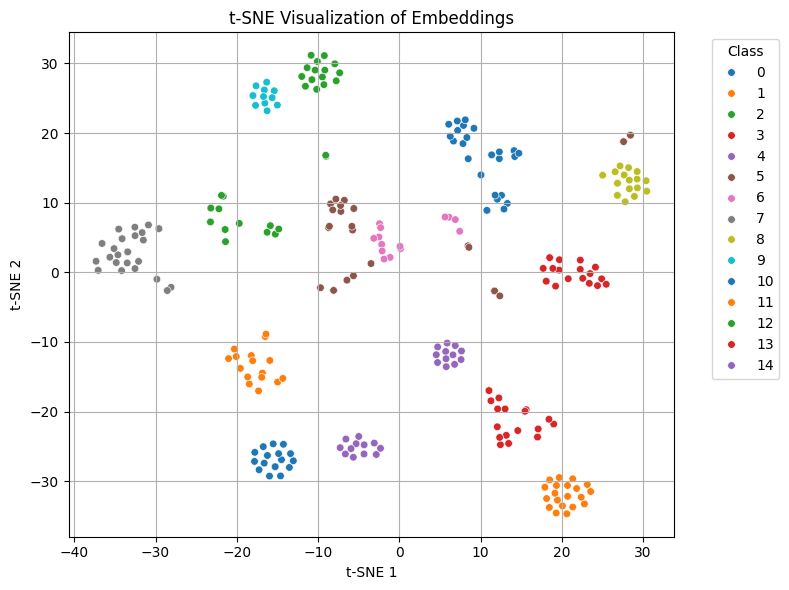

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
# Convert tensors to NumPy arrays
X = all_embeddings.cpu().numpy()
y = all_labels.cpu().numpy()


# Dynamically adjust perplexity based on sample count
n_samples = X.shape[0]

# --- t-SNE ---
tsne = TSNE(n_components=2, max_iter=1000, perplexity=20, random_state=42, metric="cosine")
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10', legend='full', s=30)
plt.title("t-SNE Visualization of Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()
